In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.utils import resample
import tkinter as tk
from tkinter import messagebox
import random

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 1. analyse

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.1.Charger le dataset UDP Flood du CIC-DDoS2019 (exemple : fichier CSV)

In [2]:
# Charger le dataset UDP Flood du CIC-DDoS2019 (exemple : fichier CSV)
df = pd.read_csv("UDP.csv", encoding="latin1", low_memory=False)
df_numeric = df.select_dtypes(include=["number"])  # Ne garder que les colonnes numériques

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.2.Remplacer les valeurs infinies par NaN

In [3]:
# Remplacer les valeurs infinies par NaN
print("\nRemplacer les valeurs infinies par:")
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
df_numeric.fillna(0, inplace=True)  # Option : remplacer NaN par 0


Remplacer les valeurs infinies par:


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.3.Nettoyage : suppression des NaN

In [4]:
# Nettoyage : suppression des NaN
df_cleaned = df_numeric.dropna()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.4.Vérifier la taille après nettoyage

In [5]:
# Vérifier la taille après nettoyage
print("\nVérifier la taille après nettoyage:")
print(f"Taille avant nettoyage : {df.shape[0]}")
print(f"Taille après nettoyage : {df_cleaned.shape[0]}")


Vérifier la taille après nettoyage:
Taille avant nettoyage : 1048575
Taille après nettoyage : 1048575


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.5.Aperçu des premières lignes du dataset

In [6]:
# Aperçu des premières lignes du dataset
print("Aperçu du dataset :")
print(df.head())

Aperçu du dataset :
   Unnamed: 0                                Flow ID   Source IP  Source Port  \
0       15798  172.16.0.5-192.168.50.4-9401-15931-17  172.16.0.5         9401   
1      110891  172.16.0.5-192.168.50.4-9402-29997-17  172.16.0.5         9402   
2       66956  172.16.0.5-192.168.50.4-9403-29887-17  172.16.0.5         9403   
3       66144   172.16.0.5-192.168.50.4-9404-7393-17  172.16.0.5         9404   
4       72903  172.16.0.5-192.168.50.4-9405-57957-17  172.16.0.5         9405   

  Destination IP  Destination Port  Protocol Timestamp  Flow Duration  \
0   192.168.50.4             15931        17   42:57.2              1   
1   192.168.50.4             29997        17   42:57.2              0   
2   192.168.50.4             29887        17   42:57.2              1   
3   192.168.50.4              7393        17   42:57.2              1   
4   192.168.50.4             57957        17   42:57.2              1   

   Total Fwd Packets  ...   Active Std   Active Max   

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.6.Informations sur le dataset

In [7]:
# Informations sur le dataset
print("\nInformations sur le dataset :")
print(df.info())


Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1048575 non-null  int64  
 1   Flow ID                      1048575 non-null  object 
 2   Source IP                    1048575 non-null  object 
 3   Source Port                  1048575 non-null  int64  
 4   Destination IP               1048575 non-null  object 
 5   Destination Port             1048575 non-null  int64  
 6   Protocol                     1048575 non-null  int64  
 7   Timestamp                    1048575 non-null  object 
 8   Flow Duration                1048575 non-null  int64  
 9   Total Fwd Packets            1048575 non-null  int64  
 10  Total Backward Packets       1048575 non-null  int64  
 11  Total Length of Fwd Packets  1048575 non-null  int64  
 12  Total Lengt

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.7.Résumé statistique

In [8]:
# Résumé statistique
print("\nRésumé statistique :")
print(df_numeric.describe())


Résumé statistique :
         Unnamed: 0   Source Port  Destination Port      Protocol  \
count  1.048575e+06  1.048575e+06      1.048575e+06  1.048575e+06   
mean   6.197033e+04  4.642418e+04      3.322809e+04  1.698308e+01   
std    3.595460e+04  9.024081e+03      1.869130e+04  4.367386e-01   
min    0.000000e+00  0.000000e+00      0.000000e+00  0.000000e+00   
25%    3.090600e+04  3.953900e+04      1.709900e+04  1.700000e+01   
50%    6.181300e+04  4.669200e+04      3.318300e+04  1.700000e+01   
75%    9.273500e+04  5.377200e+04      4.946000e+04  1.700000e+01   
max    1.312810e+05  6.552900e+04      6.553500e+04  1.700000e+01   

       Flow Duration  Total Fwd Packets  Total Backward Packets  \
count   1.048575e+06       1.048575e+06            1.048575e+06   
mean    1.061298e+05       3.793861e+00            1.884462e-02   
std     1.431712e+06       3.937055e+00            2.084001e+00   
min     0.000000e+00       1.000000e+00            0.000000e+00   
25%     1.000000e+00 

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.8.Analyse des colonnes non numériques

In [9]:

# Analyse des colonnes non numériques
print("\nAnalyse des colonnes non numériques :")
print(df.select_dtypes(exclude=["number"]).nunique())


Analyse des colonnes non numériques :
Flow ID           1041220
Source IP             120
Destination IP        138
Timestamp            4832
SimillarHTTP           21
Label                   3
dtype: int64


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.9.Détection des outliers avec IQR

In [10]:
# Détection des outliers avec IQR
print("\nDétection des outliers avec IQR:")
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = (df_numeric < lower_limit) | (df_numeric > upper_limit)
print("\nNombre de valeurs aberrantes détectées par colonne :")
print(outliers.sum())


Détection des outliers avec IQR:

Nombre de valeurs aberrantes détectées par colonne :
Unnamed: 0              0
Source Port          9696
Destination Port        0
Protocol             1586
Flow Duration       21251
                    ...  
Idle Mean             332
 Idle Std             195
 Idle Max             332
 Idle Min             332
 Inbound             2344
Length: 82, dtype: int64


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.10.Boîte à moustaches pour Flow Duration

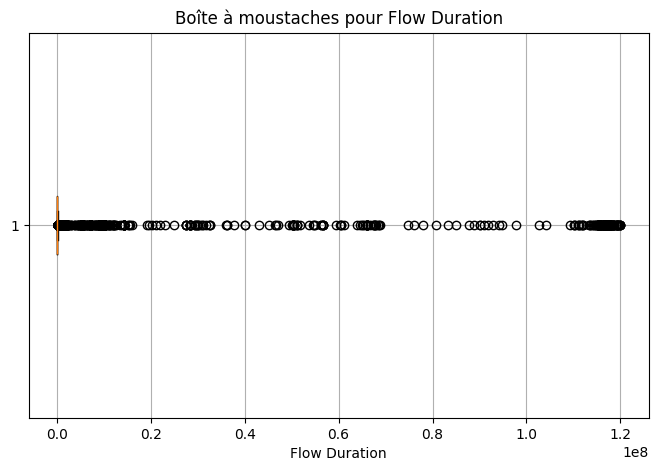

In [11]:
# Créer la boîte à moustaches pour la colonne Flow Duration
plt.figure(figsize=(8, 5))
plt.boxplot(df['Flow Duration'], vert=False)
plt.title("Boîte à moustaches pour Flow Duration")
plt.xlabel("Flow Duration")
plt.grid(True)
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.11.Visualisation des valeurs manquantes


Visualisation des valeurs manquantes:


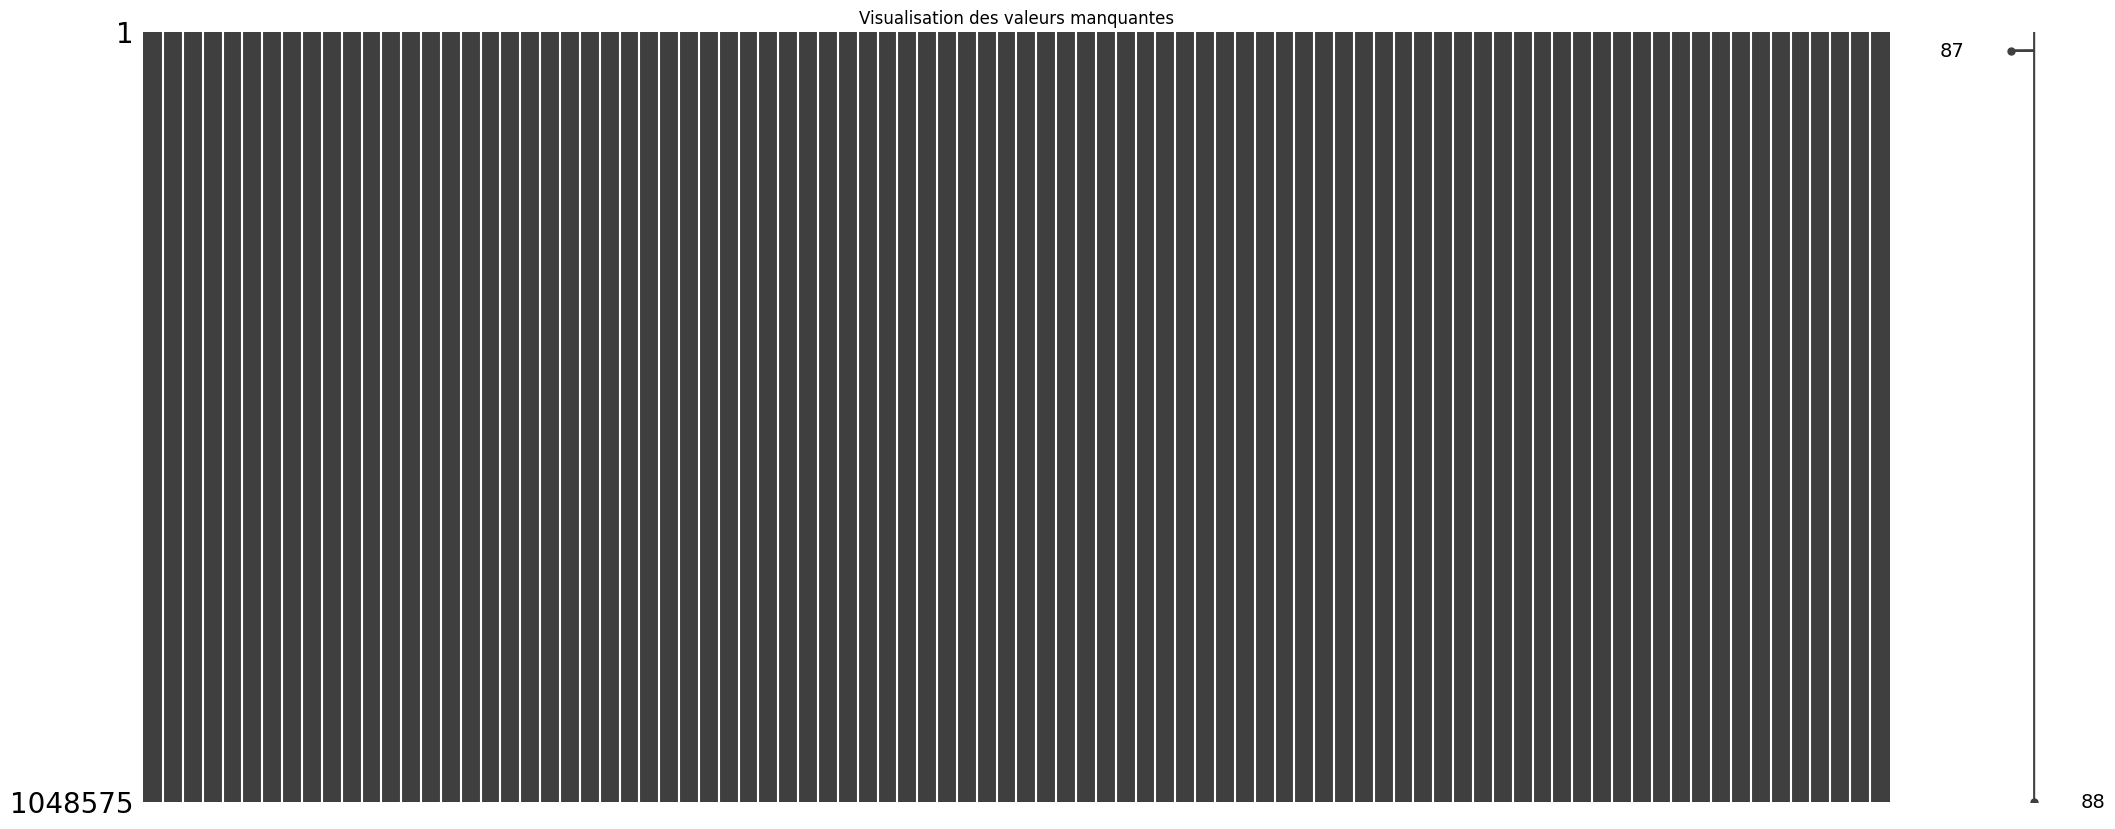

In [12]:
# Visualisation des valeurs manquantes
print("\nVisualisation des valeurs manquantes:")
msno.matrix(df)
plt.title("Visualisation des valeurs manquantes")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.12.Distribution d'une variable clé (ex : taux de paquets envoyés)


Distribution d'une variable clé (ex : taux de paquets envoyés):


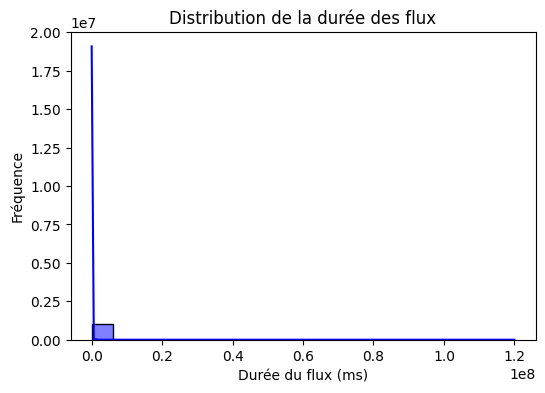

In [13]:
# Distribution d'une variable clé (ex : taux de paquets envoyés)
print("\nDistribution d'une variable clé (ex : taux de paquets envoyés):")
plt.figure(figsize=(6, 4))
sns.histplot(df['Flow Duration'], kde=True, bins=20, color="blue")
plt.title("Distribution de la durée des flux")
plt.xlabel("Durée du flux (ms)")
plt.ylabel("Fréquence")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.13.Boxplot pour analyser la distribution de certaines variables


Boxplot pour analyser la distribution de certaines variables:


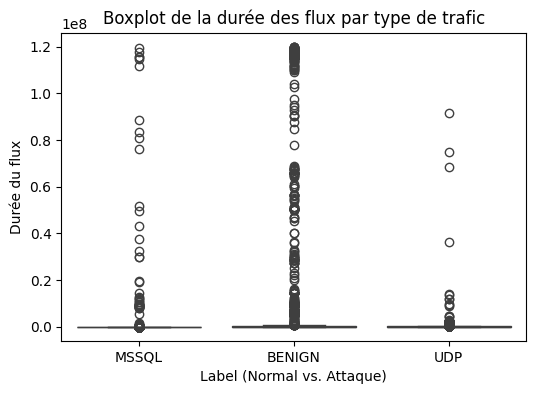

In [14]:
# Boxplot pour analyser la distribution de certaines variables
print("\nBoxplot pour analyser la distribution de certaines variables:")
plt.figure(figsize=(6, 4))
sns.boxplot(x='Label', y='Flow Duration', data=df)
plt.title("Boxplot de la durée des flux par type de trafic")
plt.xlabel("Label (Normal vs. Attaque)")
plt.ylabel("Durée du flux")
plt.show()

<span style="font-size:20px; color:#13C245 ; font-weight:bold;"> 1.14.Vérification de la taille avant échantillonnage

In [15]:
# Vérification de la taille avant échantillonnage
sample_size = min(10000, len(df_cleaned))  # Si moins de 10 000 lignes, on prend tout
df_cleaned_sample = df_cleaned.sample(n=sample_size, random_state=42)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.15.Matrice de corrélation

In [16]:
# Matrice de corrélation
print("\nMatrice de corrélation:")
corr_matrix = df_numeric.corr()
#plt.figure(figsize=(26, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', square=True, linewidths=.5,xticklabels=True, yticklabels=True)
plt.title("Matrice de Corrélation - UDP Flood")
fig = plt.gcf()  # or by other means, like plt.subplots
figsize = fig.get_size_inches()
print(figsize)
fig.set_size_inches(figsize * 7)
plt.tight_layout()
plt.savefig('correlation.png', dpi=300)
plt.close()


Matrice de corrélation:
[6.4 4.8]


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.16.isualisation des types d'attaques


Visualisation des types d'attaques:


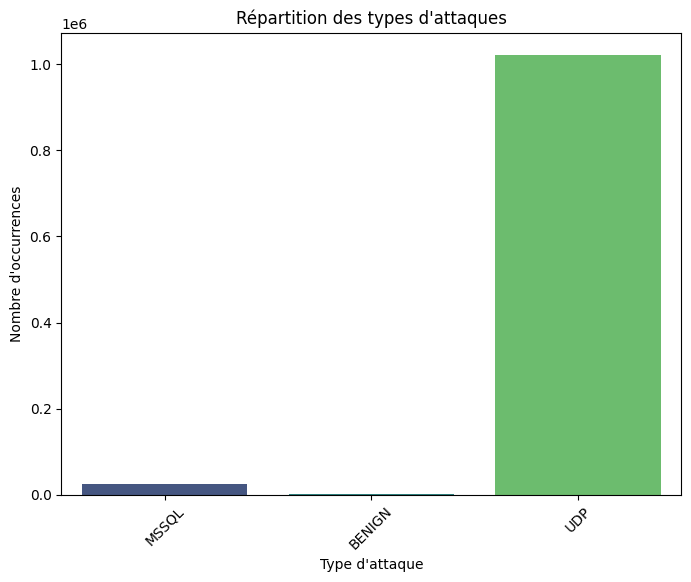

In [17]:
# Visualisation des types d'attaques
print("\nVisualisation des types d'attaques:")
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df, hue='Label', palette='viridis', legend=False)
plt.title("Répartition des types d'attaques")
plt.xlabel("Type d'attaque")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 2. K-means

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.1.Normalisation des données

In [18]:
###################################### K-means ############################################
# X = df_numeric  # Prendre uniquement les colonnes numériques
# y = df["Label"]  # Remplacez "Label" par le vrai nom de la colonne cible si différent

# Normalisation des données
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.2.Déterminer le nombre optimal de clusters (méthode du coude)


Déterminer le nombre optimal de clusters (méthode du coude):


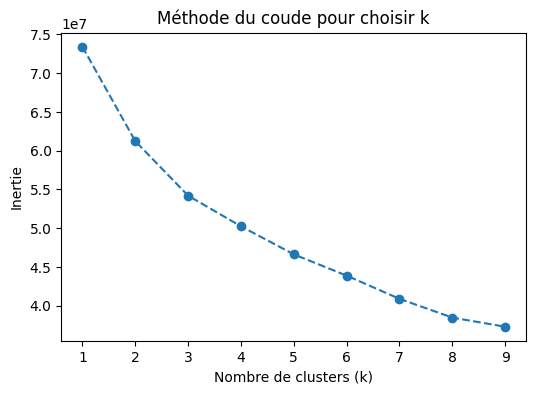

In [19]:
# Déterminer le nombre optimal de clusters (méthode du coude)
print("\nDéterminer le nombre optimal de clusters (méthode du coude):")
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans2.fit(X)
    inertia.append(kmeans2.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title("Méthode du coude pour choisir k")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.3.Application de K-means

In [20]:
# Application de K-means
kmeans = KMeans(n_clusters=5, random_state=42)  # (5) clusters pour (5) espèces
kmeans.fit(X)
# Résultats
labels = kmeans.labels_  # Attribuer chaque échantillon à un cluster
centers = kmeans.cluster_centers_  # Centres des clusters
print("\nCentres des clusters :")
print(centers)


Centres des clusters :
[[ 6.04782322e-04 -1.57567937e-02  1.88960692e-03  3.87507021e-02
  -7.40826981e-02 -4.47152011e-01 -9.04252350e-03 -4.59392949e-01
  -4.04206486e-03  4.98750054e-02  5.43153763e-01  3.63498800e-01
  -8.86712575e-01 -1.64605137e-02 -2.25161881e-02 -1.76141863e-02
  -1.54498473e-02  7.39184889e-01  7.66043149e-01 -1.92909176e-01
  -1.60897584e-01 -9.90223243e-02 -1.97790466e-03 -7.39072540e-02
  -1.76583336e-01 -1.45982694e-01 -9.90474557e-02 -1.78784369e-03
  -1.33072432e-02 -1.24360059e-02 -1.23067734e-02 -1.15876836e-02
  -1.36805260e-02 -1.89899772e-02  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.27646653e-01 -7.91711909e-03  7.66098228e-01
  -6.32455163e-03  5.43106665e-01  3.74910358e-02  3.98445847e-01
  -8.09510749e-01 -7.60864311e-02  0.00000000e+00 -3.65398843e-03
  -1.89899772e-02  0.00000000e+00 -2.13333100e-02 -3.17956456e-02
  -2.20159451e-02  0.00000000e+00 -2.94398419e-02  7.24763374e-01
   3.63498800e-01 -1.76141863e-02  1.27646653e-01  0

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.4.Réduction de la dimensionnalité (pour visualiser en 2D)


Visualisation des clusters K-means:


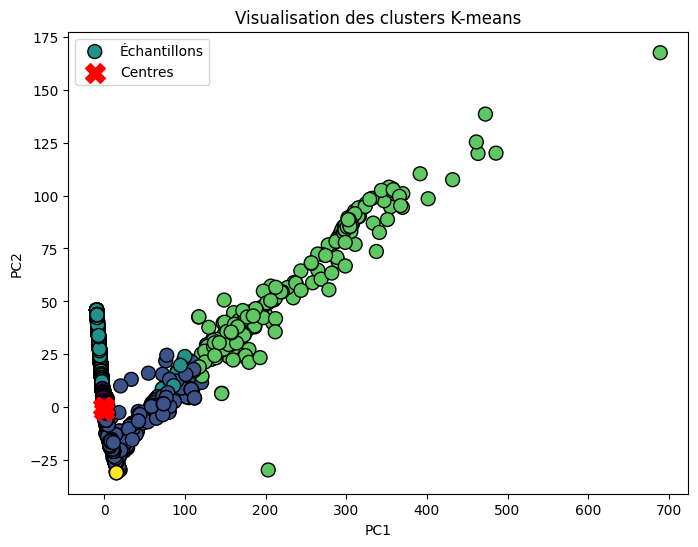

In [21]:
# Réduction de la dimensionnalité (pour visualiser en 2D)
pca = PCA(n_components=2)  # Réduire à 2 dimensions pour la visualisation
X_pca = pca.fit_transform(X)
# Visualisation des clusters
print("\nVisualisation des clusters K-means:")
plt.figure(figsize=(8, 6))
# Tracer les points colorés par cluster
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k', label='Échantillons')
# Tracer les centres des clusters
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centres')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisation des clusters K-means')
plt.legend()
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.5.Clustering hiérarchique avec échantillonnage


Clustering hiérarchique avec échantillonnage:


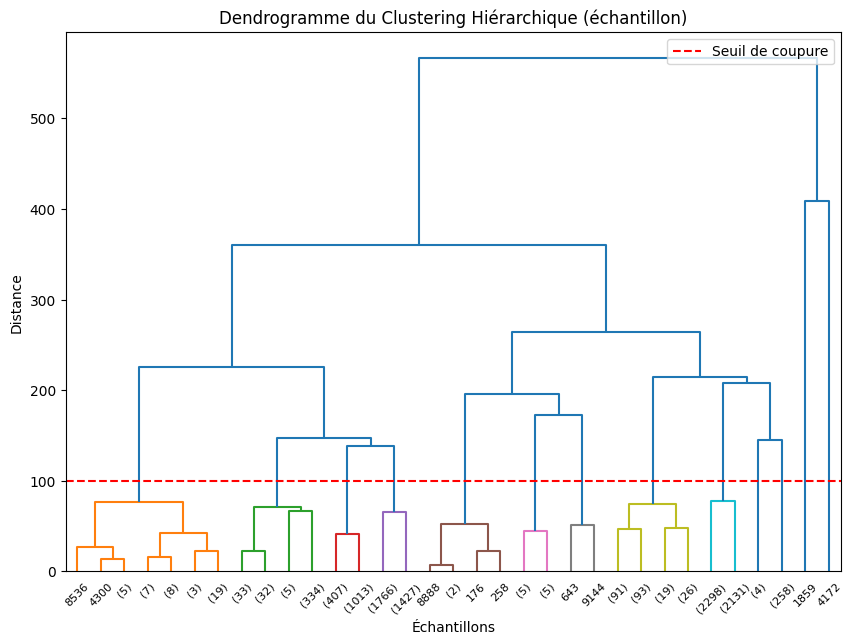

In [22]:
# Clustering hiérarchique avec échantillonnage
print("\nClustering hiérarchique avec échantillonnage:")
# Échantillonnage aléatoire de 10 000 points pour limiter la mémoire
sample_size = min(10000,len(X))  
X_sample = resample(X, n_samples=sample_size, random_state=42)

# Appliquer linkage sur cet échantillon réduit
linked = linkage(X_sample, method='ward')

# Affichage du dendrogramme
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5, color_threshold=100)
plt.axhline(y=100, color='r', linestyle='--', label="Seuil de coupure")
plt.title("Dendrogramme du Clustering Hiérarchique (échantillon)")
plt.xlabel("Échantillons")
plt.ylabel("Distance")
plt.legend()
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 3. Simulation

In [23]:
######################### Simulation ##########################################

# Fonction pour simuler le trafic normal
def simulate_normal_traffic(devices, server):
    traffic_data = []
    for device in devices:
        flow_duration = random.randint(100, 1000)  # Durée du flux en ms
        num_packets = random.randint(10, 100)     # Nombre de paquets
        traffic_data.append([device, server, flow_duration, num_packets, "Normal"])
    return pd.DataFrame(traffic_data, columns=["Source", "Destination", "Flow Duration", "Num Packets", "Label"])

# Fonction pour simuler une attaque DoS
def simulate_dos_attack(attacker_ip, server):
    traffic_data = []
    for _ in range(1000):  # Envoi de 1000 paquets
        flow_duration = random.randint(1, 10)  # Durée très courte
        num_packets = random.randint(1000, 10000)  # Nombre de paquets très élevé
        traffic_data.append([attacker_ip, server, flow_duration, num_packets, "Attack"])
    return pd.DataFrame(traffic_data, columns=["Source", "Destination", "Flow Duration", "Num Packets", "Label"])

# Fonction pour lancer la simulation
def launch_simulation():
    global all_traffic
    choice = traffic_choice.get()

    if choice == "Normal":
        all_traffic = simulate_normal_traffic(devices, server)
        show_normal_traffic_results(all_traffic)  # Afficher les résultats dans le terminal
        messagebox.showinfo("Simulation", "Simulation du trafic normal lancée !")
    elif choice == "Attack":
        all_traffic = simulate_dos_attack(attacker_ip, server)
        messagebox.showinfo("Simulation", "Simulation d'une attaque DoS lancée !")
    else:
        messagebox.showerror("Erreur", "Veuillez choisir un type de trafic.")

# Fonction pour afficher les résultats du trafic normal dans le terminal
def show_normal_traffic_results(traffic_data):
    print("\n=== Résultats du Trafic Normal ===")
    print(f"Nombre total de flux : {len(traffic_data)}")
    print(f"Durée moyenne des flux : {traffic_data['Flow Duration'].mean():.2f} ms")
    print(f"Nombre moyen de paquets par flux : {traffic_data['Num Packets'].mean():.2f}")
    print("\nAperçu des données générées :")
    print(traffic_data.head())  # Afficher les 5 premières lignes des données

# Fonction pour analyser le trafic
def analyze_traffic():
    if 'all_traffic' not in globals():
        messagebox.showerror("Erreur", "Veuillez d'abord lancer une simulation.")
        return

    # Préparation des données pour K-means
    X = all_traffic[["Flow Duration", "Num Packets"]]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Application de K-means
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_

    # Ajout des labels au DataFrame
    all_traffic["Cluster"] = labels

    # Visualisation des clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k')
    plt.xlabel("Flow Duration (scaled)")
    plt.ylabel("Num Packets (scaled)")
    plt.title("Clustering du Trafic Réseau (Normal vs. Attaque)")
    plt.show()

    # Détection de l'attaque
    if "Attack" in all_traffic["Label"].values:
        attack_cluster = all_traffic[all_traffic["Cluster"] == 1]
        print("\nTrafic détecté comme anormal (attaque) :")
        print(attack_cluster)
        messagebox.showinfo("Résultat", "Attaque détectée !")
    else:
        messagebox.showinfo("Résultat", "Aucune attaque détectée.")

# Configuration de l'interface graphique
root = tk.Tk()
root.title("Simulation de Trafic IoT")
root.geometry("400x200")

# Variables globales
devices = [f"Device_{i}" for i in range(1, 13)]  # 10 capteurs et 2 caméras
server = "Server_Central"
attacker_ip = "Attacker_IP"
traffic_choice = tk.StringVar(value="Normal")  # Choix par défaut

# Widgets de l'interface
label = tk.Label(root, text="Choisissez le type de trafic à simuler :")
label.pack(pady=10)

normal_radio = tk.Radiobutton(root, text="Trafic Normal", variable=traffic_choice, value="Normal")
normal_radio.pack()

attack_radio = tk.Radiobutton(root, text="Attaque DoS", variable=traffic_choice, value="Attack")
attack_radio.pack()

simulate_button = tk.Button(root, text="Lancer la Simulation", command=launch_simulation)
simulate_button.pack(pady=10)

analyze_button = tk.Button(root, text="Analyser le Trafic", command=analyze_traffic)
analyze_button.pack(pady=10)

# Lancer l'interface
root.mainloop()

<span style="font-size:30px;font-weight:bold;">By </br>
LARBAOUI Mohamed Rayan</br>
.Baghdadi Nadjib Aimen